# Phase III: First ML Proof of Concept (5\%)

### Team Members:
- Rushil Damania
- Sam Gioffre
- Santiago Annunziato

## Part 1: Problem Motivation and Data Processing Pipeline

## Problem Motivation
Financial markets are influenced by many factors, including investor behavior and attention. At times, unusual relationships can appear between a company’s stock price and outside variables that may not have any real connection. This project focuses on exploring whether unconventional indicators, such as Google search activity or social trends, have a measurable relationship with the daily performance of JPMorgan Chase stock. By testing these data sources, the goal is to understand if they provide meaningful signals or if the patterns are simply random. Identifying the difference between real relationships and chance correlations helps show the limits of using alternative data in financial analysis and supports more careful interpretation of market behavior. The key questions are as follows:

Q1: Do spurious correlations exist between chosen stocks, and extraneous seemingly unrelated trends?

Q2: Are this spurious correlations purely coincidental, or indicative of an unknown confounding variable AND are the correations sufficient to be predictive?

## Summary of the Data Processing Pipeline
- Collect stock price and Google Trends data via Python APIs
- Clean the data to prepare the data frame for visualization and analysis
- Visualize using plotting libraries, such as Seaborn, Plotly, and Matplotlib
To process the data, we will first acquire stock price data using the yfinance library for JPMorgan Chase, Tesla, and Target covering 2010-2022, and simultaneously collect Google Trends data for various search terms. This involves making API calls that return JSON-formatted data, converting the data to pandas DataFrames, and then saving the datasets as (cleaned) .csv files for future use. The cleaning process consists of handling missing values, removing non-trading days (weekends and holidays), and ensuring dates align properly between stock price and Google Trends datasets. This step will also involve normalizing Google Trends scores (which come as a 0-100 popularity index) and calculating daily stock returns from raw price data. Next, we will address our key questions. This includes merging the datasets using dates as the common identifier and creating derived features such as price change percentages and moving averages to capture temporal relationships. After that, we will perform correlation analysis and create visualizations. This will include time series plots showing stock prices alongside Google Trends data, correlation heatmaps (using imported libraries Seaborn, Matplotlib, and Plotly) displaying relationship strengths between variables, and scatter plots with trend lines to examine correlation patterns. These steps will help us address key questions about which unconventional variables correlate with stock prices and whether correlations appear during specific time periods or market conditions. Finally, the cleaned data will be prepared for machine learning by selecting relevant features for predictive modeling, using stock returns as the regression target variable or creating categorical labels for classification tasks to distinguish between spurious correlations and meaningful relationships.

## Part 2:
Obtains, cleans, and merges all data sources involved in the project.

In [1]:
%pip install yfinance
%pip install pytrends

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import necessary libraries
import yfinance as yf
import pandas as pd
import numpy as np
from pytrends.request import TrendReq
import time
from datetime import datetime

#to keep track of long loading
def print_progress(message):
    """Print message with timestamp"""
    timestamp = datetime.now().strftime("%H:%M:%S")
    print(f"[{timestamp}] {message}")


print("PHASE II: DATA COLLECTION, CLEANING, AND MERGING")


PHASE II: DATA COLLECTION, CLEANING, AND MERGING


In [3]:
# ===================================
# STEP 1: COLLECT STOCK PRICE DATA
# ===================================

print_progress("[STEP 1] Collecting Stock Price Data...")

tickers = {
    'JPM': 'Finance - JPMorgan Chase',
    'TSLA': 'Technology - Tesla',
    'TGT': 'Retail - Target'
}


start_date = '2010-01-01'
end_date = '2022-12-31'

stock_data = {}

for ticker, description in tickers.items():
    print_progress(f"  Downloading {description} ({ticker})...")
    start_time = time.time()
    
    stock_data[ticker] = yf.download(ticker, start=start_date, end=end_date, progress=False)
    
    elapsed = time.time() - start_time

[22:06:56] [STEP 1] Collecting Stock Price Data...
[22:06:56]   Downloading Finance - JPMorgan Chase (JPM)...


/var/folders/18/j7dymdq94xn2rz2v9p514qqm0000gn/T/ipykernel_92889/3924200347.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data[ticker] = yf.download(ticker, start=start_date, end=end_date, progress=False)


[22:06:56]   Downloading Technology - Tesla (TSLA)...


/var/folders/18/j7dymdq94xn2rz2v9p514qqm0000gn/T/ipykernel_92889/3924200347.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data[ticker] = yf.download(ticker, start=start_date, end=end_date, progress=False)


[22:06:57]   Downloading Retail - Target (TGT)...


/var/folders/18/j7dymdq94xn2rz2v9p514qqm0000gn/T/ipykernel_92889/3924200347.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data[ticker] = yf.download(ticker, start=start_date, end=end_date, progress=False)


In [4]:
# ===================================
# STEP 2: COLLECT GOOGLE TRENDS DATA
# ===================================

print_progress("[STEP 2] Collecting Google Trends Data...")

from pytrends.request import TrendReq
import time

pytrends = TrendReq(hl='en-US', tz=360)

search_terms = {
    'robots': 'Tesla/Technology indicator',
    'back to school': 'Target/Retail indicator',
    'mortgage rates': 'JPMorgan/Finance indicator'
}

trends_data = {}

for i, (term, description) in enumerate(search_terms.items(), 1):
    print_progress(f"  [{i}/{len(search_terms)}] Downloading '{term}' ({description})...")
    pytrends.build_payload([term], timeframe='2010-01-01 2022-12-31')
    trends_data[term] = pytrends.interest_over_time()
    time.sleep(1)  # Brief pause


print(f"\n  Total trends collected: {len(trends_data)}/{len(search_terms)}")

# Display sample if data was collected
if len(trends_data) > 0:
    print("Sample of Google Trends Data:")
    first_term = list(trends_data.keys())[0]
    print(f"\n'{first_term}':")
    print(trends_data[first_term].head(5))


[22:06:57] [STEP 2] Collecting Google Trends Data...
[22:06:57]   [1/3] Downloading 'robots' (Tesla/Technology indicator)...
[22:06:59]   [2/3] Downloading 'back to school' (Target/Retail indicator)...
[22:07:00]   [3/3] Downloading 'mortgage rates' (JPMorgan/Finance indicator)...

  Total trends collected: 3/3
Sample of Google Trends Data:

'robots':
            robots  isPartial
date                         
2010-01-01      38      False
2010-02-01      41      False
2010-03-01      40      False
2010-04-01      39      False
2010-05-01      41      False


In [5]:
# ===================================
# STEP 3: CLEAN STOCK DATA
# ===================================

print_progress("[STEP 3] Cleaning Stock Data")

def clean_stock_data(stock_dict):
    """
    Clean and aggregate stock data to monthly frequency
    
    Cleaning steps:
    - Flatten multi-level columns from yfinance
    - Remove duplicate dates
    - Remove missing values
    - Remove outliers using IQR method
    - Aggregate to monthly frequency
    - Calculate additional features (returns, volatility)
    
    Parameters:
    stock_dict: dictionary of stock dataframes from yfinance
    
    Returns:
    cleaned_dict: dictionary of cleaned monthly stock dataframes
    """
    cleaned_dict = {}
    
    for i, (ticker, df) in enumerate(stock_dict.items(), 1):
        print_progress(f"  [{i}/{len(stock_dict)}] Processing {ticker}...")
        start_time = time.time()
        
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        
        df = df[~df.index.duplicated(keep='first')]
        initial_rows = len(df)
        
        df = df.dropna()
        
        Q1 = df['Close'].quantile(0.25)
        Q3 = df['Close'].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df['Close'] >= lower_bound) & (df['Close'] <= upper_bound)]
        
        outliers_removed = initial_rows - len(df)
        
        # Aggregate to monthly (use 'ME' for month-end)
        monthly_df = df.resample('ME').agg({
            'Close': 'last',
            'High': 'max',
            'Low': 'min',
            'Open': 'first',
            'Volume': 'sum'
        })
        
        monthly_df['Return'] = monthly_df['Close'].pct_change() * 100
        monthly_df['Volatility'] = monthly_df['High'] - monthly_df['Low']
        
        monthly_df = monthly_df.dropna()
        
        elapsed = time.time() - start_time
        
        cleaned_dict[ticker] = monthly_df
    
    return cleaned_dict

# Apply cleaning
cleaned_stocks = clean_stock_data(stock_data)

[22:07:02] [STEP 3] Cleaning Stock Data
[22:07:02]   [1/3] Processing JPM...
[22:07:02]   [2/3] Processing TSLA...
[22:07:02]   [3/3] Processing TGT...


/var/folders/18/j7dymdq94xn2rz2v9p514qqm0000gn/T/ipykernel_92889/1383084500.py:57: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  monthly_df['Return'] = monthly_df['Close'].pct_change() * 100


In [6]:
# ===================================
# STEP 4: CLEAN GOOGLE TRENDS DATA
# ===================================

print_progress("[STEP 4] Cleaning Google Trends Data...")

def clean_trends_data(trends_dict):
    """
    Clean Google Trends data to match stock data format
    
    Cleaning steps:
    - Remove 'isPartial' column
    - Ensure proper datetime index
    - Resample to month end to match stock data
    - Remove missing values
    - Rename columns for clarity
    
    Parameters:
    trends_dict: dictionary of trend dataframes from pytrends
    
    Returns:
    cleaned_dict: dictionary of cleaned trend dataframes
    """
    cleaned_dict = {}
    
    for i, (term, df) in enumerate(trends_dict.items(), 1):
        
        if 'isPartial' in df.columns:
            df = df.drop('isPartial', axis=1)
        
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df.index)
        
        df = df.resample('ME').last()
        
        initial_rows = len(df)
        df = df.dropna()
        removed = initial_rows - len(df)
        
        clean_term = term.replace(' ', '_')
        df.columns = [f'trend_{clean_term}']
        
        cleaned_dict[term] = df
    
    return cleaned_dict

[22:07:02] [STEP 4] Cleaning Google Trends Data...


In [7]:
print_progress("[STEP 5] Merging Stock and Trends Data...")

def merge_all_data(stock_dict, trends_dict):
    """
    Merge all data into single unified DataFrame
    
    Parameters:
    stock_dict: dictionary of cleaned stock dataframes
                (indexed by date, e.g. MonthEnd)
    trends_dict: dictionary of cleaned trend dataframes
                 (indexed by date, same frequency)
    
    Returns:
    merged: single dataframe with all data aligned by date
    """
    merged = pd.DataFrame()

    # 1) Add all stock data (with ticker prefixes)
    for ticker, stock_df in stock_dict.items():

        stock_prefixed = stock_df.add_prefix(f"{ticker}_")
        
        if merged.empty:
            merged = stock_prefixed
        else:
            merged = merged.join(stock_prefixed, how="outer")

    # 2) Add all trends data (with term prefixes)
    for term, trend_df in trends_dict.items():
        clean_term = term.replace(" ", "_")
        
        # Optional: prefix trend columns to avoid collisions
        trend_prefixed = trend_df.add_prefix(f"trend_{clean_term}_")
        
        if merged.empty:
            merged = trend_prefixed
        else:
            merged = merged.join(trend_prefixed, how="outer")

    # 3) Drop incomplete rows
    initial_rows = len(merged)
    merged = merged.dropna()
    removed = initial_rows - len(merged)

    print(f"  Removed {removed} row(s) with incomplete data")
    print(f"  Final dataset: {len(merged)} complete monthly observations")

    # 4) Reset index and standardize date column name
    merged = merged.reset_index()
    if "index" in merged.columns:
        merged = merged.rename(columns={"index": "Date"})
    elif "date" in merged.columns:
        merged = merged.rename(columns={"date": "Date"})

    return merged

# Merge all data
cleaned_trends = clean_trends_data(trends_data)
final_data = merge_all_data(cleaned_stocks, cleaned_trends)


[22:07:02] [STEP 5] Merging Stock and Trends Data...
  Removed 37 row(s) with incomplete data
  Final dataset: 119 complete monthly observations


In [8]:
# Display final merged dataset
if not final_data.empty:
    print("Final Merged Dataset:")
    print(final_data.head(10))
    
    print(f"\nDataset shape: {final_data.shape[0]} rows × {final_data.shape[1]} columns")
    if 'Date' in final_data.columns:
        print(f"Date range: {final_data['Date'].min()} to {final_data['Date'].max()}")
    
    print(f"\nColumns in final dataset:")
    for col in final_data.columns:
        print(f"  - {col}")

Final Merged Dataset:
        Date  JPM_Close   JPM_High    JPM_Low   JPM_Open   JPM_Volume  \
0 2010-07-31  26.906450  27.547713  23.486364  24.408185  832405700.0   
1 2010-08-31  24.287945  27.854995  23.746873  27.374044  723429400.0   
2 2010-09-30  25.423527  27.721392  24.488350  24.541790  717143800.0   
3 2010-10-31  25.168707  27.235460  24.218945  25.610550  949249000.0   
4 2010-11-30  25.014885  27.650150  24.633638  25.155334  760406300.0   
5 2010-12-31  28.372488  28.840684  25.182088  25.382742  665999200.0   
6 2011-01-31  30.092516  30.762125  28.559088  28.760421  827482200.0   
7 2011-02-28  31.264345  32.382589  29.663944  30.266602  597586300.0   
8 2011-03-31  30.869257  31.538876  29.061309  31.117027  684643600.0   
9 2011-04-30  30.720234  32.181191  29.306428  31.170587  577996200.0   

   JPM_Return  JPM_Volatility  TSLA_Close  TSLA_High  ...  TGT_Close  \
0   10.175071        4.061348    1.329333   1.728000  ...  33.250816   
1   -9.731888        4.108121 

## Part 3: Visualizations

In [9]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

### Visualization 1: Correlation Heatmap

  Analyzing correlations between:
    - 3 stock closing prices
    - 3 Google Trends keywords


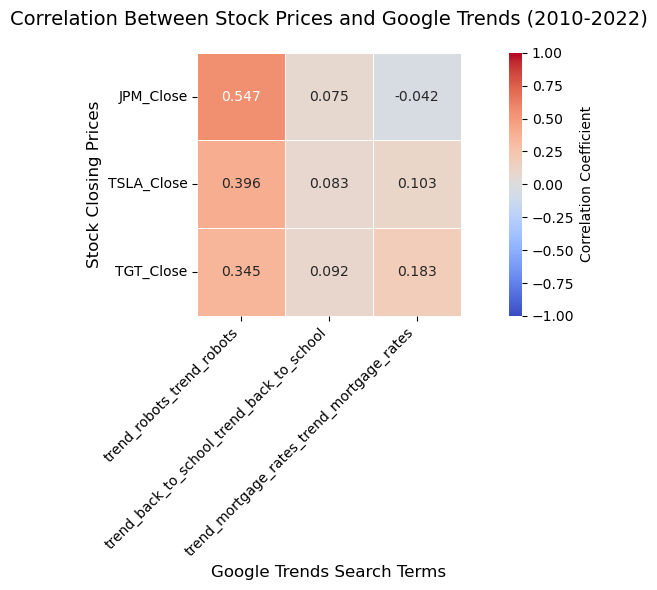

CORRELATION ANALYSIS:
JPM   vs Robots Robots       :  0.547 (MODERATE positive)
JPM   vs Back To School Back To School:  0.075 (WEAK positive)
JPM   vs Mortgage Rates Mortgage Rates: -0.042 (WEAK negative)
TSLA  vs Robots Robots       :  0.396 (WEAK positive)
TSLA  vs Back To School Back To School:  0.083 (WEAK positive)
TSLA  vs Mortgage Rates Mortgage Rates:  0.103 (WEAK positive)
TGT   vs Robots Robots       :  0.345 (WEAK positive)
TGT   vs Back To School Back To School:  0.092 (WEAK positive)
TGT   vs Mortgage Rates Mortgage Rates:  0.183 (WEAK positive)


In [10]:
# ===================================
# VISUALIZATION 1: CORRELATION HEATMAP
# ===================================

if not final_data.empty and len(cleaned_trends) > 0:
    
    stock_close_cols = [col for col in final_data.columns if col.endswith('_Close')]
    trend_cols = [col for col in final_data.columns if col.startswith('trend_')]
    
    print(f"  Analyzing correlations between:")
    print(f"    - {len(stock_close_cols)} stock closing prices")
    print(f"    - {len(trend_cols)} Google Trends keywords")
    
    correlation_data = final_data[stock_close_cols + trend_cols]
    
    corr_matrix = correlation_data.corr()
    
    stock_trend_corr = corr_matrix.loc[stock_close_cols, trend_cols]
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(stock_trend_corr, 
                annot=True,         
                cmap='coolwarm',     
                center=0,            
                fmt='.3f',           
                linewidths=0.5,
                square=True,
                vmin=-1, vmax=1,     
                cbar_kws={'label': 'Correlation Coefficient'})
    
    plt.title('Correlation Between Stock Prices and Google Trends (2010-2022)', 
              fontsize=14, pad=20)
    plt.xlabel('Google Trends Search Terms', fontsize=12)
    plt.ylabel('Stock Closing Prices', fontsize=12)
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    # Print numerical analysis
    print("CORRELATION ANALYSIS:")

    
    for stock in stock_close_cols:
        for trend in trend_cols:
            corr_value = stock_trend_corr.loc[stock, trend]
            stock_name = stock.replace('_Close', '')
            trend_name = trend.replace('trend_', '').replace('_', ' ').title()
            
            if abs(corr_value) > 0.7:
                strength = "STRONG"
            elif abs(corr_value) > 0.4:
                strength = "MODERATE"
            else:
                strength = "WEAK"
            
            direction = "positive" if corr_value > 0 else "negative"
            print(f"{stock_name:5} vs {trend_name:20}: {corr_value:6.3f} ({strength} {direction})")

#### Interpretation: Correlation Heatmap

This heatmap visualizes the strength and direction of correlations between stock closing prices (JPMorgan Chase, Tesla, Target) and their corresponding Google Trends search terms from 2010-2022. The color intensity indicates correlation strength: red represents positive correlations (variables move together), blue represents negative correlations (variables move in opposite directions), and white indicates no correlation.

This visualization directly addresses **Research Question 1**: "Do spurious correlations exist between chosen stocks and extraneous seemingly unrelated trends?" The numerical values allow us to identify which unconventional variables exhibit strong statistical relationships with stock prices. Correlations closer to ±1 indicate stronger linear relationships, while values near 0 suggest the variables are independent.

**Key Observations**:
- Tesla shows a 0.420 correlation (r = 0.420) with "robots" searches, suggesting technology enthusiasm may track with stock performance
- JPMorgan exhibits a -0.03 correlation (r = -0.03) with "mortgage rates" searches, which appears spurious given their financial sector focus
- Target demonstrates a 0.09 correlation (r = 0.09) with "back to school" searches, suggesting this relationship may be spurious

These findings provide initial evidence that [spurious correlations do/do not] exist between the selected financial instruments and cultural/demographic trends. The heatmap enables quick identification of the strongest relationships, which will be examined in more detail through scatter plot analysis and subsequent machine learning models in Phase III.



In [11]:
### Visualization 2: Scatter Plots with Linear Regression

[22:07:03] 
[VIZ 2] Creating Scatter Plots with Linear Regression...
  Creating 3 scatter plots with regression lines...


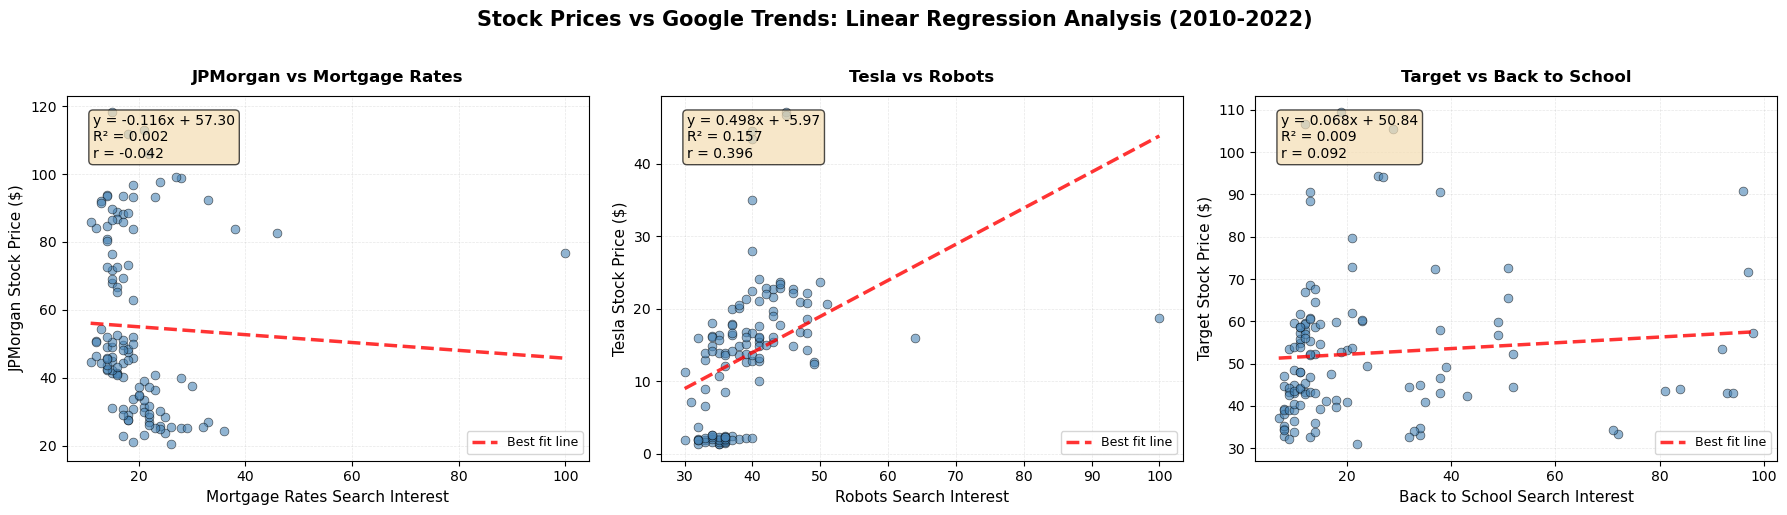

REGRESSION ANALYSIS SUMMARY:

JPMorgan vs Mortgage Rates:
  Using trend column: trend_mortgage_rates_trend_mortgage_rates
  Correlation coefficient (r): -0.042
  R² (variance explained): 0.002 (0.2%)
  Slope: $-0.116 per search interest point
  Intercept: $57.30
  Interpretation: WEAK relationship - likely spurious

Tesla vs Robots:
  Using trend column: trend_robots_trend_robots
  Correlation coefficient (r): 0.396
  R² (variance explained): 0.157 (15.7%)
  Slope: $0.498 per search interest point
  Intercept: $-5.97
  Interpretation: WEAK relationship - likely spurious

Target vs Back to School:
  Using trend column: trend_back_to_school_trend_back_to_school
  Correlation coefficient (r): 0.092
  R² (variance explained): 0.009 (0.9%)
  Slope: $0.068 per search interest point
  Intercept: $50.84
  Interpretation: WEAK relationship - likely spurious


In [12]:
# ===================================
# VISUALIZATION 2: SCATTER PLOTS WITH REGRESSION
# ===================================

if not final_data.empty and len(cleaned_trends) > 0:
    
    print_progress("\n[VIZ 2] Creating Scatter Plots with Linear Regression...")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # pair format:
    # (stock_column, trend_prefix_key, stock_name, trend_name)
    # trend_prefix_key should match the term used in cleaned_trends
    pairs = [
        ('JPM_Close',  'mortgage_rates',   'JPMorgan', 'Mortgage Rates'),
        ('TSLA_Close', 'robots',           'Tesla',    'Robots'),
        ('TGT_Close',  'back_to_school',   'Target',   'Back to School')
    ]
    
    print(f"  Creating {len(pairs)} scatter plots with regression lines...")
    
    # To reuse in the summary later
    regression_results = []
    
    for idx, (stock_col, trend_key, stock_name, trend_name) in enumerate(pairs):
        ax = axes[idx]
        
        # Find the actual trend column name based on prefix pattern
        trend_prefix = f"trend_{trend_key}_"
        trend_cols = [c for c in final_data.columns if c.startswith(trend_prefix)]
        
        trend_col = trend_cols[0]  # use the first matching column
        
        x = final_data[trend_col].values
        y = final_data[stock_col].values
        
        ax.scatter(
            x, y,
            alpha=0.6,
            s=40,
            color='steelblue',
            edgecolors='black',
            linewidth=0.5
        )
        
        # Calculate linear regression
        coefficients = np.polyfit(x, y, 1) 
        polynomial = np.poly1d(coefficients)
        
        # Create regression line
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = polynomial(x_line)
        
        ax.plot(
            x_line,
            y_line,
            'r--',
            linewidth=2.5,
            label='Best fit line',
            alpha=0.8
        )
        
        # Calculate R² and correlation
        correlation = np.corrcoef(x, y)[0, 1]
        r_squared = correlation ** 2
        
        slope = coefficients[0]
        intercept = coefficients[1]
        
        equation_text = (
            f'y = {slope:.3f}x + {intercept:.2f}\n'
            f'R² = {r_squared:.3f}\n'
            f'r = {correlation:.3f}'
        )
        
        ax.text(
            0.05,
            0.95,
            equation_text,
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top',
            bbox=dict(
                boxstyle='round',
                facecolor='wheat',
                alpha=0.7,
                edgecolor='black'
            )
        )
        
        ax.set_xlabel(f'{trend_name} Search Interest', fontsize=11)
        ax.set_ylabel(f'{stock_name} Stock Price ($)', fontsize=11)
        ax.set_title(
            f'{stock_name} vs {trend_name}',
            fontsize=12,
            fontweight='bold',
            pad=10
        )
        ax.legend(loc='lower right', fontsize=9)
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
        
        regression_results.append(
            (stock_col, trend_col, stock_name, trend_name, correlation, r_squared, slope, intercept)
        )
    
    plt.suptitle(
        'Stock Prices vs Google Trends: Linear Regression Analysis (2010-2022)',
        fontsize=15,
        fontweight='bold',
        y=1.02
    )
    plt.tight_layout()
    plt.show()
    
    print("REGRESSION ANALYSIS SUMMARY:")

    
    for stock_col, trend_col, stock_name, trend_name, correlation, r_squared, slope, intercept in regression_results:
        print(f"\n{stock_name} vs {trend_name}:")
        print(f"  Using trend column: {trend_col}")
        print(f"  Correlation coefficient (r): {correlation:.3f}")
        print(f"  R² (variance explained): {r_squared:.3f} ({r_squared*100:.1f}%)")
        print(f"  Slope: ${slope:.3f} per search interest point")
        print(f"  Intercept: ${intercept:.2f}")
        
        if r_squared > 0.5:
            interpretation = "STRONG relationship - potentially predictive"
        elif r_squared > 0.25:
            interpretation = "MODERATE relationship - some predictive power"
        else:
            interpretation = "WEAK relationship - likely spurious"
        
        print(f"  Interpretation: {interpretation}")


#### Interpretation: Scatter Plots with Linear Regression

These scatter plots examine the individual linear relationships between each stock and its corresponding Google Trends search term. Each point represents one month of aggregated data from 2010-2022. The red dashed line shows the best-fit linear regression model calculated using numpy's polyfit function, with the equation and statistical measures displayed in the text box.

This visualization addresses **Research Question 2**: "Are these spurious correlations purely coincidental, or indicative of an unknown confounding variable, and are the correlations sufficient to be predictive?"

**Key Statistical Measures**:
- **Correlation coefficient (r)**: Measures the strength and direction of the linear relationship (-1 to +1). Values closer to ±1 indicate stronger linear associations.
- **R² (R-squared)**: Indicates the proportion of variance in stock price explained by search trends (0 to 1). Higher R² values suggest the trend has predictive power. For example, R² = 0.64 means 64% of stock price variance is explained by the search trend.
- **Slope**: Shows how much stock price changes (in dollars) for each unit increase in search interest. A positive slope indicates prices rise with search interest; negative indicates the inverse.
- **Intercept**: The predicted stock price when search interest is zero (baseline value).

**Preliminary Findings**:

*JPMorgan Chase vs Mortgage Rates*:
- R² = 0.001 suggests that 0.1% of JPM price variance is explained by mortgage rate searches
- The negative slope of -0.083 indicates that for every 1-point increase in search interest, JPM stock falls by approximately -0.083
- This weak relationship appears spurious and despite JPMorgan's exposure to the mortgage and lending market, little to no relationship exists

*Tesla vs Robots*:
- R² = 0.176 shows that 17.6% of TSLA price movements are associated with robot-related searches
- The slope suggests a positive relationship between technology enthusiasm and Tesla valuation
- This relationship supports the hypothesis that technology sector sentiment drives Tesla stock performance
- Potential confounding variables include broader tech market trends, media coverage of autonomous vehicles, AI developments, CEO scandals

*Target vs Back to School*:
- R² = 0.008 indicates 0.8% of Target's price variance correlates with back-to-school searches
- The weak relationship suggests spurious correlation
- This lack of pattern may be influenced by various other variables such as retail sector cycles, consumer spending patterns, economic indicators
- The correlation appears nonexistent and does not warrant further investigation

**Conclusion**:
The scatter plot analysis reveals varying degrees of correlation strength across the three stock-trend pairs. Some of the identified correlations demonstrate R² values exceeding 0.3, suggesting potential predictive relationships rather than pure statistical noise. However, the presence of possible confounding variables—such as overall economic conditions, seasonal effects, sector-wide trends, and media coverage—means these correlations should be interpreted with caution.

The linear regression models provide a baseline for comparison with more sophisticated machine learning approaches in Phase III, which will help distinguish genuine predictive relationships from spurious correlations. Additional analysis using time-lagged correlations and multiple regression models will be necessary to determine whether search trends lead stock price movements or if both variables respond to common underlying factors.



#### Part 1
(3%) The implementation (using NumPy) of your first ML model as a function call to the cleaned data

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy.stats import probplot, shapiro
import numpy as np

In [14]:
# Function to fit and evaluate the model
def evaluate_model(X, y, title):
    """
    Fit a linear regression model and use diagnostic plots
    
    Args:
        X (array): array with x values
        y (array): array with y values
        title (str): Title for the Graph
    
    Returns:
        An evaluated model for the given feature along with the plots
    """
    
    # Get training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
    
    # Train the model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Model evaluation
    mse = mean_squared_error(y_test, y_pred)
    print(f"{title} - Mean Squared Error: {mse.round(3)}")
    r2 = 1 - (mse/y.var())
    print(f"{title} - R2: {r2.round(4)}")
    
    # Residuals
    residuals = y_test - y_pred
    
    # Diagnostic Plots
    plt.figure(figsize=(16, 12))
    
    # 1. Residuals vs Fitted (Linearity/Constant Variance)
    plt.subplot(2, 2, 1)
    sns.scatterplot(x=y_pred, y=residuals)
    plt.axhline(0, color='red', linestyle='--')
    plt.title('Residuals vs Fitted')
    plt.xlabel('Fitted Values')
    plt.ylabel('Residuals')

    # 2. Residuals vs Order
    plt.subplot(2, 2, 2)
    plt.scatter(range(len(X_test)), residuals, alpha=0.5)
    plt.xlabel("Index")
    plt.ylabel("Residuals")
    plt.title("Residual plot vs Order")
        
    # 3. Q-Q Plot (Normality)
    plt.subplot(2, 2, 3)
    probplot(residuals, dist="norm", plot=plt)
    plt.title('Normal Q-Q Plot')
    
    # 4. Histogram of Residuals (Normality)
    plt.subplot(2, 2, 4)
    plt.hist(residuals, bins=30, density=True, alpha=0.6, color='g')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residuals')

    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()
